# Complex numbers arising from cubics

In this notebook, we're going to use a little computer algebra to talk about how imaginary numbers arise in the context of cubics. It might seem that complex numbers arise more naturally in the solutions of quadratics like
$$x^2 + 1 = 0$$
This is not how complex numbers arose historcially, though, simply because it's easy to assume that such equations are meaningless. As it turns out, though, complex numbers arise in solution of the general cubic - even when the solutions are manifestly real. This played an important role in their acceptance.

## A surprising cubic

Let's ask SageMath to solve 
$$x^3 - 3x - 1 = 0:$$

In [1]:
surprising_solutions = solve(x^3 - 3*x - 1 == 0, x)
for sol in surprising_solutions:
    pretty_print(sol)

x == -1/2*(I*sqrt(3) + 1)*(1/2*I*sqrt(3) + 1/2)^(1/3) - 1/2*(-I*sqrt(3) + 1)/(1/2*I*sqrt(3) + 1/2)^(1/3)

x == -1/2*(1/2*I*sqrt(3) + 1/2)^(1/3)*(-I*sqrt(3) + 1) - 1/2*(I*sqrt(3) + 1)/(1/2*I*sqrt(3) + 1/2)^(1/3)

x == (1/2*I*sqrt(3) + 1/2)^(1/3) + 1/(1/2*I*sqrt(3) + 1/2)^(1/3)

Note that all three roots are expressed in terms of the imaginary unit $i$. Of course, every cubic with real coefficients has at least one real root. In fact, a simple look at a plot shows that all three roots of this polynomial are real:

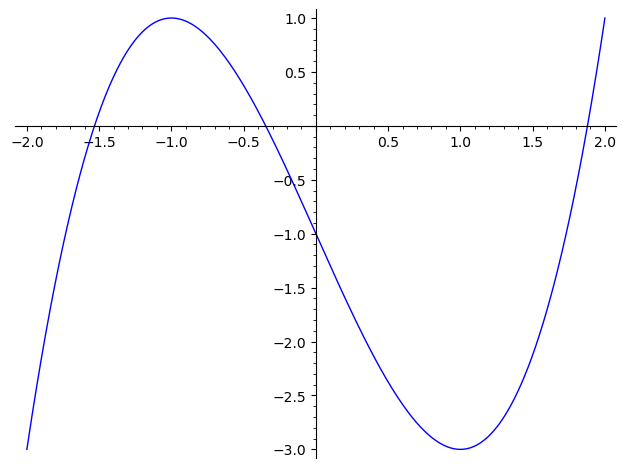

In [2]:
plot(x^3 - 3*x - 1, [x,-2,2])

So, why do these expressions involve $i$? Can the expression be rewritten in terms of only real expressions?

If you restrict yourself to just [algebraic expressions](https://en.wikipedia.org/wiki/Algebraic_expression), the answer is *no*! Closed form algebraic expressions for the roots of this polynomial *must* involve imaginary numbers.

### Viete's formula

It's worth mentioning that the roots can be expressed in terms of trig functions without reference to $i$:

In [3]:
surprising_solutions = solve(x^3 - 3*x - 1 == 0, x)
for sol in surprising_solutions:
    pretty_print(sol.simplify_full())

x == sqrt(3)*sin(1/9*pi) - cos(1/9*pi)

x == -sqrt(3)*sin(1/9*pi) - cos(1/9*pi)

x == 2*cos(1/9*pi)

This follows from [Viete's formula](https://en.wikipedia.org/wiki/Cubic_equation?utm_source=chatgpt.com#Trigonometric_solution_for_three_real_roots), which asserts that, if the roots of 
$$x^3 + px + q = 0$$
are all real, then they can be expressed as
$$\frac{2 \sqrt{-p} \cos \left(\frac{2 \pi  k}{3}-\frac{1}{3} \arccos\left(\frac{3 \sqrt{3} \sqrt{-\frac{1}{p}} q}{2p}\right)\right)}{\sqrt{3}}.$$
There's a different root for each choice of $k \, \text{ mod } 3$ so that there are three roots.

This is not an algebraic expression, though, as it explicitly involves the transcendental cosine and arccosine functions. More to the point, this is not the type of formula that $16^{\text{th}}$ century mathematicians were looking for when they were forced by cubics to accept complex numbers.

## The depressed cubic

A *depressed cubic* is a monic cubic with no square term. Thus, we can write it in the form
$$g(y) = y^3 + p \, y + q.$$
Or, in Sage code:

In [4]:
var('y,p,q')
g(y) = y^3 + p*y + q

We're going to derive a formula for the general solution to this using Sage to do a bit of the algebraic work for us. We begin by plugging in $u+v$ and expanding:

In [5]:
var('u,v')
expand(g(u+v))

u^3 + 3*u^2*v + 3*u*v^2 + v^3 + p*u + p*v + q

Note that we've got 
$$(u^3 + v^3 + q) + (3\,u^2\,v + 3\,u\,v^2 + p\,u + p\,v).$$
Let's factor that more complicated looking second bunch of stuff:

In [6]:
factor(3*u^2*v + 3*u*v^2 + p*u + p*v)

(3*u*v + p)*(u + v)

This might all seem a bit mysterious. Our objective, though, is to express $g$ in a simpler form in terms of these new variables $u$ and $v$ - which will be related. Note, for example, that if we choose 
$$v=-\frac{p}{3u},$$
then that second bunch is zero and we should have a simpler expression for our cubic. In fact, let's just plug in
$$u + v = u - \frac{p}{3u}$$
straight away:

In [7]:
g(u - p/(3*u)).collect(u)

u^3 + q - 1/27*p^3/u^3

Note that if we multiply that through by $u^3$, we obtain a quadratic in $u^3$, which we can solve for $u^3$. We can then take the real cube root and plug back in to $u-p/(3u)$ to get the roots of $g$.

Since we're using SageMath, we can just solve for $u^3$ directly:

In [8]:
# Define a single variable to represent u^3:
var('u3')

# Solve and pretty print the solutions:
h(u3) = u3 + q - 1/27*p^3/u3
sols = solve(h(u3), u3, solution_dict=True)
v3 = sols[1][u3]
u3 = sols[0][u3]
pretty_print(u3)
pretty_print(v3)

-1/2*q - 1/18*sqrt(12*p^3 + 81*q^2)

-1/2*q + 1/18*sqrt(12*p^3 + 81*q^2)

The two solutions look exactly as if they might arise from the quadratic formula.

Now, remember that `u3` was shorthand for $u^3$ and that `v` was already defined via `v=-p/(3u)`.  Thus, I guess that `v3` should be shorthand for $v^3=-p^3/(27u^3)$.  If we had solved for `v3` in the first place, the roles would've been switched and $u^3=-p^3/(27v^3)$.

The point here is that the function $z \to -p^3/(27z)$ maps from one root of $z + q - 1/27*p^3/z$ to the conjugate root and those two roots are produced by the two pretty print statements above. We can double check that as follows:

In [9]:
(-p^3/(27*u3) - v3).simplify_full()

0

Putting this all together, here's our formula for a root of the depressed cubic
$$y^3 + p \, y + q = 0:$$

In [10]:
pretty_print(u3^(1/3) + v3^(1/3))

(-1/2*q + 1/18*sqrt(12*p^3 + 81*q^2))^(1/3) + (-1/2*q - 1/18*sqrt(12*p^3 + 81*q^2))^(1/3)

Once you have one root, you can (in principle) use long division to obtain a quadratic whose roots tell you the other two.

More better is to use the other cube roots; that's a little down the road, though.

## Examples

Let's apply this formula to a couple of examples.

### Example 1

Consider $x^3 - 15x - 4$ so that $p=-15$ and $q=-4$. This is exactly the [example shown here in our text](https://complexanalysis.org/web/sec_origin.html#sec_origin-2-10).

Asking Sage to do the arithmetic for us, we get:

In [11]:
p = -15
q = -4
a = -q/2
b = sqrt(12*p^3 + 81*q^2)/18
print(f"a = {a}")
print(f"b = {b}")

a = 2
b = 11*I


Thus, one root should have the form
$$\sqrt[3]{2+11i} + \sqrt[3]{2-11i}.$$
If we assume that the root is real, then these must be complex conjugates of one another. That is, there are real numbers $u$ and $v$ with 
$$(u + v \, i)^3 = 2+11i \text{ and } (u - v \, i)^3 = 2-11i.$$
If we expand these equations we obtain four real equations in the two real unknowns $u$ and $v$. As often happens in complex variables, these equations are actually consistent and redundant. That is, we can expand the left hand side of one, like so:

In [12]:
var('u,v')
expand((u + v*I)^3 == (2+11*I))

u^3 + 3*I*u^2*v - 3*u*v^2 - I*v^3 == (11*I + 2)

We can then set real and imaginary parts equal to one another and solve:

In [13]:
solve([u^3 - 3*u*v^2 == 2, 3*u^2*v - v^3 == 11], [u,v])

[[u == -1/2*sqrt(-4*sqrt(3) + 7), v == -sqrt(3) - 1/2],
 [u == -1/2*sqrt(4*sqrt(3) + 7), v == sqrt(3) - 1/2],
 [u == -I*sqrt(3) - 1, v == -1/2*I*sqrt(3) - 1/2],
 [u == I*sqrt(3) - 1, v == 1/2*I*sqrt(3) - 1/2],
 [u == 2, v == 1],
 [u == (0.9330127018922191 - 1.6160254037844384*I),
  v == (-0.6160254037844388 + 1.0669872981077808*I)],
 [u == (0.9330127018922193 + 1.6160254037844386*I),
  v == (-0.6160254037844388 - 1.0669872981077808*I)],
 [u == (0.06698729810778227 + 0.1160254037844424*I),
  v == (1.1160254037844388 + 1.9330127018922196*I)],
 [u == (0.06698729810778227 - 0.11602540378444239*I),
  v == (1.1160254037844388 - 1.9330127018922196*I)]]

If we're looking for a real root, perhaps, we should select $u=2$ and $v=1$. That is,

$$\sqrt[3]{2+11i} + \sqrt[3]{2-11i} = (2-i) + (2+i) = 4.$$

This exactly the [the solution shown in our text](https://complexanalysis.org/web/sec_origin.html#Depressed_Cubic). It's easy enough to check that $4$ is, indeed a solution:

$$4^3 - 15\times4 - 4 = 64-60-4=0.$$
With that root in hand, it's not hard to factor the polynomial to get

$$x^3 - 15x - 4 = (x^2 + 4*x + 1)(x-4).$$
The remaining quadratic doesn't factor further over the reals but it's easy to apply the quadratic formula.

## Example 2

Consider $x^3 - 3x - 1$, which we already know from a graph to have three real roots but for which Sage produced these solutions involving $i$:

In [14]:
for sol in surprising_solutions:
    pretty_print(sol)

x == -1/2*(I*sqrt(3) + 1)*(1/2*I*sqrt(3) + 1/2)^(1/3) - 1/2*(-I*sqrt(3) + 1)/(1/2*I*sqrt(3) + 1/2)^(1/3)

x == -1/2*(1/2*I*sqrt(3) + 1/2)^(1/3)*(-I*sqrt(3) + 1) - 1/2*(I*sqrt(3) + 1)/(1/2*I*sqrt(3) + 1/2)^(1/3)

x == (1/2*I*sqrt(3) + 1/2)^(1/3) + 1/(1/2*I*sqrt(3) + 1/2)^(1/3)

We can now apply what we've learned to see how these complex expressions arise:

In [15]:
p = -3
q = -1
a = -q/2
b = sqrt(12*p^3 + 81*q^2)/18
print(f"a = {a}")
print(f"b = {b}")

a = 1/2
b = 1/2*sqrt(-3)


Thus, one solution can be written as

In [16]:
z0 = (a + b)^(1/3) + (a - b)^(1/3)
pretty_print(z0)

(1/2*sqrt(-3) + 1/2)^(1/3) + (-1/2*sqrt(-3) + 1/2)^(1/3)

This looks a touch different from the solution provided by Sage:

In [17]:
pretty_print(surprising_solutions[2])

x == (1/2*I*sqrt(3) + 1/2)^(1/3) + 1/(1/2*I*sqrt(3) + 1/2)^(1/3)

We can use numerical evaluation, though, to show that these are real and equal:

In [18]:
N(z0)

1.87938524157182

In [19]:
N(surprising_solutions[2].rhs())

1.87938524157182

While it might be nice to push this farther, it's not actually feasible in this case. In fact, it can be proved that

> If $f(x) is an irreducible cubic polynomial with real roots, then any algebraic representation of those roots *must* contain the imaginary unit.

## The general cubic

Finally, it's worth mentioning that our solution for the depressed cubic can be applied to solve the general cubic:
$$z^3 + a\,z^2 + b\,z + c = 0.$$

In [20]:
var('a,b,c, y,z,t')
p(z) = z^3 + a*z^2 + b*z + c
expand(p(z+t)).collect(z)

a*t^2 + t^3 + (a + 3*t)*z^2 + z^3 + b*t + (2*a*t + 3*t^2 + b)*z + c

Note that, if we set $t = -a/3$, then the $z^2$ term is gone and we obtain depressed cubic:

In [21]:
expand(p(y-a/3)).collect(y)

2/27*a^3 + y^3 - 1/3*a*b - 1/3*(a^2 - 3*b)*y + c

Since $y$ and $z$ are related via $z=y-a/3$, it's easy to obtain the solution to the original cubic.